# Figure 01 -- force error vs expansion order

Loads `results/validation/force_error_vs_order.json`, produced by `bench/validation/force_error_vs_order.py`. No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.repo_root() / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


worst cross-basis relative gap 1.545e-13 at ('solidfmm', 'uniform', 8)


wrote /export/home/tbuck/jaccpot-paper-wt/results/figures/fig01_force_error_vs_order.pdf


'/export/home/tbuck/jaccpot-paper-wt/results/figures/fig01_force_error_vs_order.pdf'

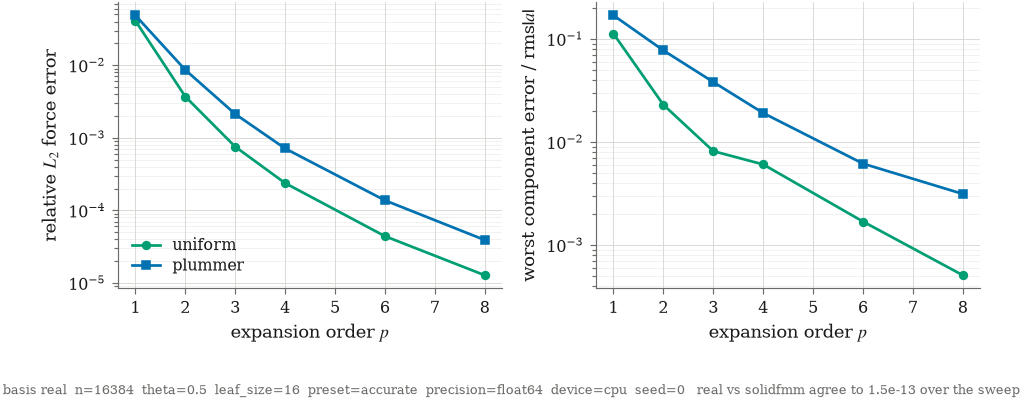

In [2]:
art = jsonio.read_result("validation/force_error_vs_order.json")
cfg, recs = art["config"], art["data"]["records"]

bases = list(cfg["basis"])
dists = list(cfg["distribution"])

# The real and solidfmm bases agree to float64 round-off at every point of this
# sweep (ratio 1.0000, max |diff| 4.5e-13 -- solidfmm and complex are in fact
# bit-identical, being the same code path). Drawing them as two curves therefore
# hides one behind the other and says nothing. Plot one basis, and report the
# cross-basis agreement as its own number: two independent expansion bases
# reproducing each other to round-off is a stronger cross-validation statement
# than two indistinguishable lines.
ref_basis = bases[0]
idx = {(r["basis"], r["distribution"], r["order"]): r for r in recs}
worst_gap, worst_at = 0.0, None
for (b, d, o), r in idx.items():
    other = idx.get((ref_basis, d, o))
    if b == ref_basis or other is None or not other["rel_l2"]:
        continue
    gap = abs(r["rel_l2"] - other["rel_l2"]) / other["rel_l2"]
    if gap > worst_gap:
        worst_gap, worst_at = gap, (b, d, o)

fig, axes = style.figure(width=style.TWO_COL, height=2.7, ncols=2, sharex=True)
for ax, field, label in (
    (axes[0], "rel_l2", "relative $L_2$ force error"),
    (axes[1], "worst_component", "worst component error / rms$|a|$"),
):
    for di, dist in enumerate(dists):
        sel = sorted(
            (r for r in recs if r["basis"] == ref_basis and r["distribution"] == dist),
            key=lambda r: r["order"],
        )
        if not sel:
            continue
        ax.plot(
            [r["order"] for r in sel],
            [r[field] for r in sel],
            marker=style.MARKERS[di % len(style.MARKERS)],
            color=style.CATEGORICAL[di % len(style.CATEGORICAL)],
            label=dist,
        )
    ax.set_yscale("log")
    ax.set_xlabel("expansion order $p$")
    ax.set_ylabel(label)
    style.finish(ax, legend=(ax is axes[0]), legend_kwargs={"loc": "lower left"})

agreement = ""
if worst_at is not None:
    agreement = f"   {' vs '.join(bases)} agree to {worst_gap:.1e} over the sweep"
    print(f"worst cross-basis relative gap {worst_gap:.3e} at {worst_at}")

fig.tight_layout()
# Both the config and the cross-basis agreement go in the footer: inside the axes
# the note grazed the first Plummer marker, and a caption over data is worse than
# a caption below the figure.
fig.tight_layout()
style.footer(
    fig,
    f"basis {ref_basis}  " + jsonio.config_caption(
        cfg, ["n", "theta", "leaf_size", "preset", "precision", "device", "seed"]
    ) + agreement,
)
style.save(fig, FIG_DIR / "fig01_force_error_vs_order.pdf")


## Caption

Force error against an exact direct summation as a function of expansion order
$p$, at fixed $N$ and opening angle, for the real (Dehnen) and solidfmm bases on
a uniform cube and a Plummer sphere. **Left:** relative $L_2$ error over the whole
acceleration field. **Right:** the largest single-component error, normalised by
the rms $|a|$ -- reported alongside the $L_2$ norm because an $L_2$ norm averages
away the tail that actually limits an integrator. Exact configuration is
annotated; all values are read from
`results/validation/force_error_vs_order.json`.
